# 02 · Denoising & Convolutional Autoencoders — Learning to *Undo* Corruption

In notebook 01 the autoencoder's target was **the input itself**. That has a subtle danger: a
powerful network can learn the lazy **identity** function ("copy pixels through") and understand
nothing. This notebook introduces the single most elegant fix — the **Denoising Autoencoder
(DAE)** — and, along the way, the **convolutional** architecture that makes autoencoders work well
on images.

**What you will learn here**

1. The key idea of a DAE: **corrupt the input, but ask for the clean original back**. Now the network
   *cannot* copy — it must understand structure to remove the noise.
2. The **manifold view**: a DAE learns to **project noisy points back onto the data manifold**.
3. Why **convolutions** beat fully-connected layers for images (locality + weight sharing), and how
   `Conv2d` / `ConvTranspose2d` build an encoder/decoder.
4. Train a **convolutional DAE on MNIST** and see clean digits emerge from heavy noise.
5. A second corruption — **masking / inpainting** — reconstructing whole missing patches.
6. The modern payoff: *a denoising autoencoder is the conceptual seed of **diffusion models**.*

> Framework: **PyTorch**, CPU-only. Data: **MNIST** (auto-downloaded once by `torchvision`).


## 1. The idea: don't copy the input — *repair* it

A plain autoencoder minimises $\lVert x - g(f(x)) \rVert^2$. A **denoising** autoencoder changes one
thing: we feed a **corrupted** copy $\tilde{x}$ but still ask for the **clean** $x$ as the target.

$$ \tilde{x} = x + \text{noise} \qquad\Longrightarrow\qquad \mathcal{L} = \big\lVert\, x - g\big(f(\tilde{x})\big) \,\big\rVert^2 $$

```
     CLEAN x        add noise         NOISY x̃                             CLEAN x̂
        │        (only at train)         │                                   │
        ▼                                ▼                                    ▼
   ┌─────────┐    corruption      ┌───────────┐   z    ┌───────────┐   reconstruct
   │  image  │ ─────────────────▶ │  ENCODER  │ ─────▶ │  DECODER  │ ───────────────▶  compare to x
   └─────────┘                    └───────────┘        └───────────┘        │
        │                                                                   │
        └────────────────────── target = the ORIGINAL clean image ─────────┘
                         loss pulls x̂  toward  x  (NOT toward x̃)
```

Why this is clever: the network can **no longer cheat** by copying its input, because its input is
*wrong* (noisy) and its target is *right* (clean). To succeed it must learn "what a real digit looks
like" strongly enough to **rebuild the parts the noise destroyed**. Denoising is therefore a built-in
**regularizer** that forces genuinely useful features — even with a wide (overcomplete) bottleneck.


### The manifold view (the picture that makes it click)

Real images don't fill all of pixel-space — they live on a thin, curved **manifold** (the set of
"plausible digits"). Adding noise **pushes a point off** that manifold. A denoising autoencoder
learns a **vector field that points back toward the manifold**: given an off-manifold noisy point,
it returns the nearest on-manifold clean point.

```
      pixel space (784-D, drawn as 2-D)

        ●  x̃  (noisy: knocked OFF the manifold)
         \
          \  the DAE learns this arrow:  x̃ ──▶ x̂
           ▼
    ~~~~~~~●~~~~~~~~   the data manifold
           x̂ ≈ x       (surface of "real digits")
```

This is exactly why DAEs learn good representations: to know *which way is back to the manifold*,
the encoder must understand the manifold's shape. (Hold onto this arrow-toward-the-manifold picture —
in notebook 05 the same idea reappears, and it is literally the mechanism behind modern **diffusion
models**, which are denoising autoencoders trained at many noise levels.)


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""   # force CPU cleanly (no CUDA-driver warning)
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms

torch.manual_seed(0); np.random.seed(0)
print("torch", torch.__version__, "| device: CPU")


torch 2.12.1+cu130 | device: CPU


## 2. The data: MNIST (real 28×28 handwriting)

We graduate from the tiny 8×8 digits to real **MNIST** — 28×28 grayscale handwritten digits. We
load the raw pixel tensor directly (fast) and use a **subset** so everything stays CPU-friendly.
Pixels are scaled to `[0, 1]`.


X_train: (12000, 1, 28, 28) | X_test: (2000, 1, 28, 28) | range: 0.0 - 1.0


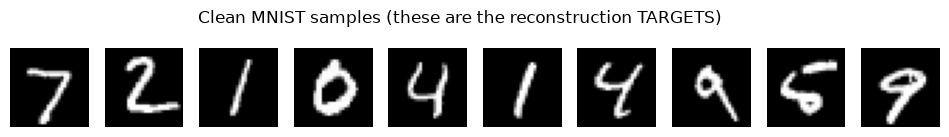

In [2]:
# torchvision downloads MNIST once into autoencoders/data (then caches it).
train_ds = torchvision.datasets.MNIST("autoencoders/data", train=True,  download=True)
test_ds  = torchvision.datasets.MNIST("autoencoders/data", train=False, download=True)

# .data is a uint8 tensor (N, 28, 28). Scale to [0,1] and add a channel dim -> (N, 1, 28, 28).
N_TRAIN, N_TEST = 12000, 2000
X_train = (train_ds.data[:N_TRAIN].float() / 255.0).unsqueeze(1)
X_test  = (test_ds.data[:N_TEST].float()  / 255.0).unsqueeze(1)
print("X_train:", tuple(X_train.shape), "| X_test:", tuple(X_test.shape),
      "| range:", float(X_train.min()), "-", float(X_train.max()))

fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for ax, img in zip(axes, X_test):
    ax.imshow(img.squeeze(), cmap="gray"); ax.axis("off")
fig.suptitle("Clean MNIST samples (these are the reconstruction TARGETS)"); plt.show()


### Define the corruption

We add **Gaussian noise** and clamp back into `[0, 1]`. Crucially, corruption happens **on the fly
during training** (fresh noise every batch), so the model sees endless variations and can't memorise
a specific noisy image. `NOISE` controls severity.


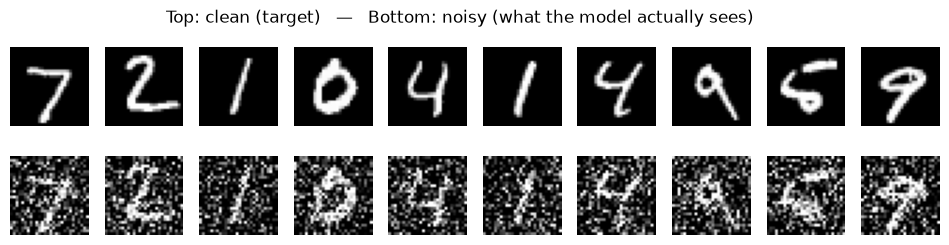

In [3]:
NOISE = 0.5   # standard deviation of the additive Gaussian noise

def add_noise(x, sigma=NOISE):
    """Corrupt a batch of clean images with additive Gaussian noise, kept in [0,1]."""
    return (x + sigma * torch.randn_like(x)).clamp(0.0, 1.0)

# Visualise clean vs noisy
noisy_demo = add_noise(X_test[:10])
fig, axes = plt.subplots(2, 10, figsize=(12, 2.6))
for j in range(10):
    axes[0, j].imshow(X_test[j].squeeze(), cmap="gray"); axes[0, j].axis("off")
    axes[1, j].imshow(noisy_demo[j].squeeze(), cmap="gray"); axes[1, j].axis("off")
fig.text(0.5, 0.95, "Top: clean (target)   —   Bottom: noisy (what the model actually sees)",
         ha="center", fontsize=12)
plt.show()


## 3. Why convolutions for images?

A fully-connected layer on a 28×28 image has 784 inputs and treats every pixel pair as independent —
it must *relearn* what an "edge" is at every location, needing huge numbers of weights. Images have
two properties an MLP ignores:

- **Locality** — a pixel relates most to its neighbours (strokes, edges, corners are local).
- **Translation invariance** — a "7" is a "7" wherever it sits in the frame.

A **convolution** exploits both: a small filter (e.g. 3×3) slides across the whole image, reusing the
**same weights** everywhere (weight sharing). This gives far fewer parameters and features that
generalise across positions.

For the **encoder** we use `Conv2d` with `stride=2` to **halve** the spatial size at each step
(28→14→7), compressing. For the **decoder** we use `ConvTranspose2d` ("deconvolution") to **double**
the size back up (7→14→28), expanding.

```
 ENCODER (downsample, learn WHAT)        DECODER (upsample, rebuild WHERE)
  28×28×1                                                       28×28×1
     │ Conv2d stride2                              ConvT stride2 ▲
  14×14×16                                                    14×14×16
     │ Conv2d stride2                              ConvT stride2 ▲
   7×7×32   ─────────  the code z (32·7·7)  ──────────▶      7×7×32
```


In [4]:
class ConvDenoisingAE(nn.Module):
    def __init__(self):
        super().__init__()
        # ENCODER: shrink spatial size, grow channels  (28 -> 14 -> 7)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  nn.ReLU(),  # -> 16 x 14 x 14
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), nn.ReLU(),  # -> 32 x 7 x 7  (the code)
        )
        # DECODER: grow spatial size back, shrink channels  (7 -> 14 -> 28)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # -> 14x14
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  nn.Sigmoid()# -> 28x28
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = ConvDenoisingAE()
print(model)
print("\nparameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("code shape for a batch of 2:", tuple(model.encoder(X_test[:2]).shape))


ConvDenoisingAE(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

parameters: 9,569
code shape for a batch of 2: (2, 32, 7, 7)


## 4. Train the denoiser

The loop is ordinary supervised learning with one twist highlighted below: **the input is the noisy
image, the target is the clean image**. Fresh noise is drawn each batch.


epoch  1 | train 0.1547 | test 0.1026


epoch  2 | train 0.0636 | test 0.0340


epoch  3 | train 0.0258 | test 0.0215


epoch  4 | train 0.0189 | test 0.0182


epoch  5 | train 0.0170 | test 0.0169


...

epoch  8 | train 0.0153 | test 0.0155


epoch  9 | train 0.0151 | test 0.0153


epoch 10 | train 0.0149 | test 0.0151


epoch 11 | train 0.0148 | test 0.0150


epoch 12 | train 0.0147 | test 0.0149


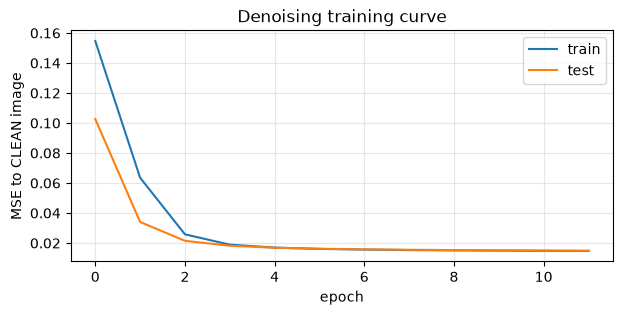

In [5]:
import torch.optim as optim

model = ConvDenoisingAE()
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

EPOCHS, BATCH = 12, 128
n = len(X_train)
hist = []
for epoch in range(EPOCHS):
    model.train(); perm = torch.randperm(n); running = 0.0
    for i in range(0, n, BATCH):
        clean = X_train[perm[i:i+BATCH]]          # TARGET  = clean image
        noisy = add_noise(clean)                   # INPUT   = corrupted image  (fresh noise)
        out = model(noisy)
        loss = loss_fn(out, clean)                 # <-- pull output toward CLEAN, not noisy
        opt.zero_grad(); loss.backward(); opt.step()
        running += loss.item() * len(clean)
    # test reconstruction error (fixed noise for a fair comparison across epochs)
    model.eval()
    with torch.no_grad():
        torch.manual_seed(123)
        test_loss = loss_fn(model(add_noise(X_test)), X_test).item()
    hist.append((running / n, test_loss))
    print(f"epoch {epoch+1:2d} | train {running/n:.4f} | test {test_loss:.4f}")

h = np.array(hist)
plt.figure(figsize=(7, 3))
plt.plot(h[:, 0], label="train"); plt.plot(h[:, 1], label="test")
plt.xlabel("epoch"); plt.ylabel("MSE to CLEAN image"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Denoising training curve"); plt.show()


## 5. The result: clean digits from heavy noise

Three rows: the **clean** original (unseen target), the **noisy** input the model received, and the
model's **denoised** output. The autoencoder never saw these test images during training, and the
noise is fresh — yet it reconstructs recognisable digits.


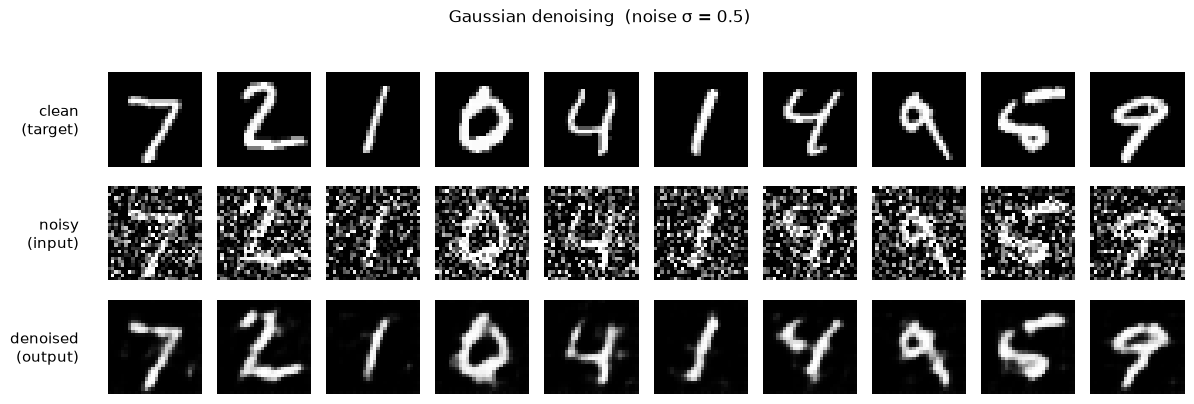

In [6]:
model.eval()
torch.manual_seed(7)
clean = X_test[:10]
noisy = add_noise(clean)
with torch.no_grad():
    denoised = model(noisy)

fig, axes = plt.subplots(3, 10, figsize=(12, 4))
rows = [("clean\n(target)", clean), ("noisy\n(input)", noisy), ("denoised\n(output)", denoised)]
for r, (label, imgs) in enumerate(rows):
    for j in range(10):
        axes[r, j].imshow(imgs[j].detach().squeeze(), cmap="gray"); axes[r, j].axis("off")
    axes[r, 0].text(-9, 14, label, ha="right", va="center", fontsize=11)
fig.suptitle(f"Gaussian denoising  (noise σ = {NOISE})", y=1.02)
plt.tight_layout(); plt.show()


## 6. A different corruption: masking → **inpainting**

Denoising isn't limited to additive noise. If we corrupt by **blanking out a square patch**, the same
setup teaches the model to **fill in missing regions** — a task called **inpainting**. Same recipe:
corrupt the input, ask for the clean original. This shows DAEs learn *content*, not just a noise
filter — the model must infer the hidden pixels from context.


inpaint epoch  4 | train 0.0233


inpaint epoch  8 | train 0.0236


inpaint epoch 12 | train 0.0224


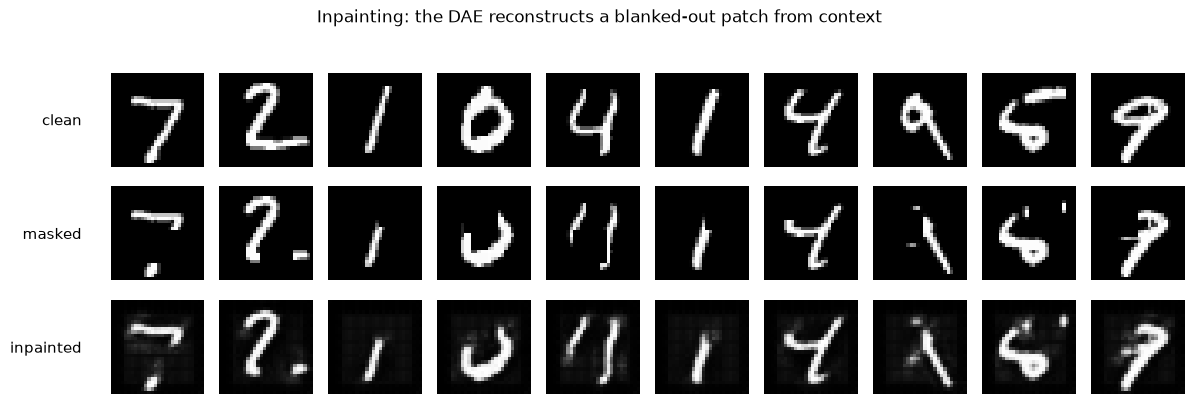

In [7]:
def mask_patch(x, size=10):
    """Blank out a random square patch in each image (occlusion / missing-data corruption)."""
    x = x.clone()
    B, _, H, W = x.shape
    for b in range(B):
        top = torch.randint(0, H - size + 1, (1,)).item()
        left = torch.randint(0, W - size + 1, (1,)).item()
        x[b, :, top:top+size, left:left+size] = 0.0
    return x

inpaint = ConvDenoisingAE()
opt = optim.Adam(inpaint.parameters(), lr=1e-3)
for epoch in range(12):
    inpaint.train(); perm = torch.randperm(n)
    for i in range(0, n, BATCH):
        clean = X_train[perm[i:i+BATCH]]
        masked = mask_patch(clean)                 # INPUT = image with a hole
        loss = loss_fn(inpaint(masked), clean)     # TARGET = whole image
        opt.zero_grad(); loss.backward(); opt.step()
    if (epoch+1) % 4 == 0:
        print(f"inpaint epoch {epoch+1:2d} | train {loss.item():.4f}")

inpaint.eval()
torch.manual_seed(3)
clean = X_test[:10]; masked = mask_patch(clean)
with torch.no_grad():
    filled = inpaint(masked)
fig, axes = plt.subplots(3, 10, figsize=(12, 4))
for r, (label, imgs) in enumerate([("clean", clean), ("masked", masked), ("inpainted", filled)]):
    for j in range(10):
        axes[r, j].imshow(imgs[j].detach().squeeze(), cmap="gray"); axes[r, j].axis("off")
    axes[r, 0].text(-9, 14, label, ha="right", va="center", fontsize=11)
fig.suptitle("Inpainting: the DAE reconstructs a blanked-out patch from context", y=1.02)
plt.tight_layout(); plt.show()


## 7. Sanity check: does denoising actually help vs. a plain AE?

A quick, honest comparison. We take the **same architecture** and train one copy as a **plain
autoencoder** (clean→clean) and evaluate both on the *denoising* job (noisy→clean) on the test set.
The plain AE was never asked to remove noise, so it should do worse at cleaning — quantifying the
value of the denoising objective.


MSE to clean, on NOISY test inputs (lower is better):
  do nothing (identity)     : 0.1156
  plain AE (clean->clean)   : 0.0508
  denoising AE (noisy->clean): 0.0149   <-- trained for the job


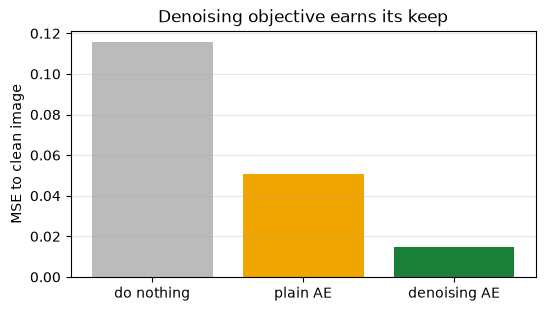

In [8]:
plain = ConvDenoisingAE()
opt = optim.Adam(plain.parameters(), lr=1e-3)
for epoch in range(12):
    plain.train(); perm = torch.randperm(n)
    for i in range(0, n, BATCH):
        clean = X_train[perm[i:i+BATCH]]
        loss = loss_fn(plain(clean), clean)        # plain AE: clean -> clean (no noise anywhere)
        opt.zero_grad(); loss.backward(); opt.step()

plain.eval()
with torch.no_grad():
    torch.manual_seed(123); noisy_test = add_noise(X_test)
    dae_err   = loss_fn(model(noisy_test), X_test).item()   # our denoising AE
    plain_err = loss_fn(plain(noisy_test), X_test).item()   # plain AE asked to denoise
    identity_err = loss_fn(noisy_test, X_test).item()       # do-nothing baseline (keep the noise)

print(f"MSE to clean, on NOISY test inputs (lower is better):")
print(f"  do nothing (identity)     : {identity_err:.4f}")
print(f"  plain AE (clean->clean)   : {plain_err:.4f}")
print(f"  denoising AE (noisy->clean): {dae_err:.4f}   <-- trained for the job")

plt.figure(figsize=(6, 3.2))
plt.bar(["do nothing", "plain AE", "denoising AE"], [identity_err, plain_err, dae_err],
        color=["#bbb", "#f0a500", "#1a7f37"])
plt.ylabel("MSE to clean image"); plt.title("Denoising objective earns its keep"); plt.grid(alpha=0.3, axis="y")
plt.show()


## 8. Key takeaways & interview soundbites

**The mental model**

- A **denoising autoencoder** corrupts the input but targets the **clean** original. It *cannot* learn
  the identity, so it is forced to learn the **structure of the data** — a free, powerful regularizer.
- Geometrically, a DAE learns to **project off-manifold (noisy) points back onto the data manifold**.
- **Convolutions** are the right tool for image autoencoders: `Conv2d` (stride 2) downsamples in the
  encoder, `ConvTranspose2d` upsamples in the decoder. Fewer weights, position-invariant features.
- The *corruption* defines the *task*: Gaussian noise → denoising; masking → **inpainting**;
  you could also drop pixels, blur, or lower resolution (→ super-resolution).

**Sharp answers for an interview**

- *"Why is a denoising AE better than a vanilla AE for representation learning?"* → The vanilla AE can
  collapse to identity and learn nothing, especially if overcomplete. Denoising removes that shortcut:
  the only way to fill in destroyed information is to model the data distribution, so the features are
  more robust and useful downstream.
- *"Where would you use this in a consulting project?"* → Cleaning scanned documents / sensor signals,
  imputing missing values in tabular data (masking = missingness), pre-training features on unlabeled
  data before a small labeled fine-tune, or as a robustness layer in front of a classifier.
- *"Any connection to modern generative models?"* → Yes — **diffusion models** (Stable Diffusion, etc.)
  are essentially denoising autoencoders trained to remove noise at *many* levels; sampling repeatedly
  applies the learned "arrow back to the manifold". A DAE is the one-step seed of that idea.

**Try it yourself**

1. Push `NOISE` to 0.8 — reconstructions degrade gracefully; the model hallucinates a plausible digit.
2. Change the masking `size` and watch inpainting get harder.
3. Feed a *test* image corrupted with a noise type the model never trained on — does it still help?
4. Extract `model.encoder(x)` as features and reuse them in a classifier (preview of notebook 04).
